# Example: Updating Single-Asset GBM Parameters with EMA
The [out-of-sample example](CHEME-5660-L5a-Example-OOS-SAGBM-Fall-2026.ipynb) keeps the fitted GBM parameters fixed throughout 2025. What happens if we give recent observations more weight as new prices arrive? In this example, we use an exponential moving average (EMA) to update mean growth and volatility, then compare the resulting forecasts with the frozen model.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Update mean growth and volatility:** Initialize the mean and variance of growth rates from the 2014–2024 estimates and update them using exponential weights. Explain how the half-life determines the influence of recent observations.
> * **Construct forecasts with updated estimates:** Use only observations available at each forecast date and hold the parameter estimates fixed over the chosen forward window. Compare simulations and target probabilities using frozen estimates, updated volatility, and updated mean growth with volatility.
> * **Evaluate whether updating helps:** Compare the methods on the same observed outcomes using Brier scores. Distinguish estimates that respond to new observations from estimates that improve predictions.

We use the NPV target from the [trade-rule example](CHEME-5660-L5a-Example-GBM-NPV-TradeRule-Fall-2026.ipynb) to evaluate the forecasts. The original purchase remains fixed while we assess possible sale dates a chosen number of trading observations ahead. The entry index, forward window, benchmark, and EMA half-life are adjustable.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, loads the required packages, and includes local helper code.

Let's set up our code environment:

In [1]:
# Load the course environment and the local EMA and forecast-comparison helpers -
include(joinpath(@__DIR__, "Include.jl")); # resolve the setup file from this notebook's directory

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [course package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here. The local [adaptive-forecast function reference](docs/adaptive-functions.md) links to the documented source helpers.

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from January 2, 2025 until December 31, 2025, along with data for several exchange-traded funds and volatility products during that time period.

Let's load the `original_dataset::Dict{String,DataFrame}` by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet).

In [2]:
# Load held-out 2025 prices; fitted parameters will come from the earlier training period -
original_dataset = MyTestingMarketDataSet() |> x -> x["dataset"]; # load the testing data by ticker

Now, let's load the GBM parameters estimated from the 2014 to 2024 training data in [the L4b parameter-estimation example](../../week-4/L4b/CHEME-5660-L4b-Example-Parameters-SAGBM-Fall-2026.ipynb). We store the table in the `parameters_df::DataFrame` variable. The legacy `drift` column contains the mean growth rate estimate $\hat{\mu}_g$, and the `volatility` column contains $\hat{\sigma}$. We will convert mean growth to arithmetic GBM drift when we build the model.

In [3]:
parameters_df = let

    # Load the saved 2014–2024 estimates -
    # The legacy drift column is mean growth μ̂_g; the model needs μ̂_g + σ̂²/2.
    df = CSV.read(joinpath(_PATH_TO_DATA,"SAGBM-Parameters-Fall-2025.csv"), DataFrame);
    df; # retain ticker names so subsequent lookups do not depend on CSV row order
end;

### Match the Training Estimates and Testing Histories
The training parameter table and testing dataset contain different sets of tickers. We need both fitted parameters and a complete price history on the common 2025 date grid. AAPL supplies the complete reference grid; the [eligible_gbm_data(...) function](docs/adaptive-functions.md#eligible_gbm_data) also checks alignment, positive prices, and valid estimates. It returns the eligible tickers and a table explaining every exclusion.

> __Data and payoff convention:__ Eligibility uses complete histories available through 2025, so these results describe the selected evaluation sample rather than the investible universe known at the entry date. We use daily volume-weighted average price (VWAP) as the entry/sale price proxy. Our NPV is price-based and excludes dividend cash flows. Daily VWAP is observed after the day's interval; it is not a promised intraday execution price.


In [4]:
# Match parameters and complete testing histories by ticker and actual date -
eligible = eligible_gbm_data(original_dataset, parameters_df);
dataset = eligible.dataset; # ticker → aligned 2025 prices
list_of_tickers = eligible.tickers; # common selectable and evaluated universe
observation_dates = eligible.dates; # the same date grid for every retained ticker
exclusions_df = eligible.exclusions; # retain every excluded ticker and its reason
println("Eligible tickers: $(length(list_of_tickers)); observations per ticker: $(length(observation_dates))")
println("Date range: $(Date(first(observation_dates))) to $(Date(last(observation_dates)))")
pretty_table(combine(groupby(exclusions_df, :reason), nrow => :count));


Eligible tickers: 417; observations per ticker: 250
Date range: 2025-01-02 to 2025-12-31
┌───────────────────────────────────────┬───────┐
│                                reason │ count │
│                                String │ Int64 │
├───────────────────────────────────────┼───────┤
│                  No training estimate │    59 │
│ Incomplete or unaligned testing dates │     7 │
└───────────────────────────────────────┴───────┘


The count table describes exclusions from the union of testing tickers and parameter-table tickers. The full `exclusions_df` remains available for inspection.

### Constants and Parameters
Choose the entry row, the number of trading intervals to the prospective sale, and the benchmark before examining the outcome. A 21-day window contains 21 transitions and 22 prices. The EMA half-life controls how quickly older observations lose influence, independently of that window.


In [5]:
# Choose one asset and one original purchase, then reuse them throughout -
ticker_to_simulate = "SPY"; # editable example ticker
start_day_index = 1; # one-based purchase and first forecast row in the aligned 2025 data
holding_period_days = 21; # forward trading intervals; 1 means the next observation
Δt = 1/252; # years per trading interval
g_y = 0.05; # annual continuously compounded benchmark growth rate (1/year)
rho_star = 0.0; # target scaled NPV; zero means beating the benchmark
ema_half_life_days = 21; # observations required to halve an older observation's weight
λ = 2.0^(-1/ema_half_life_days); # decay per observation, separate from the forecast window
number_of_paths = 100; # simulated paths shown in price figures
random_seed = 5660; # reproduce the simulations
Random.seed!(random_seed);

# Validate the entry and complete forward window rather than silently clipping dates -
@assert ticker_to_simulate in list_of_tickers "Select an eligible ticker"
@assert start_day_index isa Integer && start_day_index >= 1 "Use a positive integer start index"
@assert holding_period_days isa Integer && holding_period_days >= 1 "Use a positive integer holding period"
@assert start_day_index + holding_period_days <= length(observation_dates) "The full holding window must be observed"
@assert number_of_paths > 0 "The simulation count must be positive"
first_sale_index = start_day_index + holding_period_days;
random_firm_data = dataset[ticker_to_simulate];
prices = Float64.(random_firm_data.volume_weighted_average_price);
println("$(ticker_to_simulate): buy $(Date(observation_dates[start_day_index])); first prospective sale $(Date(observation_dates[first_sale_index]))")

SPY: buy 2025-01-02; first prospective sale 2025-02-04


___

## Task 1: Update Mean Growth and Volatility
In this task, we initialize the parameter estimates from the training period, update them as each 2025 price is observed, and plot how they change relative to the baseline.

Why update parameters if GBM assumes they are constant? We use GBM as a local forecast model. Its parameters remain fixed over each forecast window, then we fit a new local model after another observation arrives. Updating can respond to observed changes; it cannot anticipate the next unobserved shock.

Let $g_k=\ln(S_k/S_{k-1})/\Delta t$ be the observed growth rate, with $\Delta t$ in years and $g_k$ in $\mathrm{year}^{-1}$. Initialize its mean $m_s$ and variance $v_s$ at entry row $s$ from the training estimates:

$$
m_s=\hat\mu_{g,0},\qquad v_s=\frac{\hat\sigma_0^2}{\Delta t}.
$$

Under GBM, $\operatorname{Var}(g_k)=\sigma^2/\Delta t$, so $v_k$ has units of $\mathrm{year}^{-2}$. The training mean-growth estimate comes from log-price regression. We use it to initialize the mean growth; it need not equal the sample mean of the training growth rates. For each new observation, $\delta_k$ measures how far its growth rate lies from the previous mean. We move the mean partway toward that observation and update the variance around the changing mean using:

$$
\begin{aligned}
\delta_k&=g_k-m_{k-1},\\
m_k&=m_{k-1}+(1-\lambda)\delta_k,\\
v_k&=\lambda\left[v_{k-1}+(1-\lambda)\delta_k^2\right].
\end{aligned}
$$

Here, $\lambda=2^{-1/H_{\mathrm{half}}}$ and $H_{\mathrm{half}}$ is the half-life in trading observations. An observation's weight halves after that many further observations. With the default 21-observation half-life, $\lambda\approx0.9675$: the updated mean assigns about 96.75% weight to the previous mean and 3.25% to the newest growth-rate observation. An observation above the previous mean raises the estimate; one below it lowers the estimate.

The variance update retains $\lambda v_{k-1}$ from the previous variance and adds $\lambda(1-\lambda)\delta_k^2$. A larger departure from the previous mean contributes more to the updated variance. The factor $\lambda(1-\lambda)$ accounts for the change in the weighted mean, as developed in the [EMA derivation](advanced/ema-derivation/CHEME-5660-L5a-Derivation-EMA-SAGBM-Fall-2026.ipynb). This is a weighted population moment, without a finite-sample unbiased correction. We update growth-rate variance before converting it to GBM volatility.

The updated mean is already our estimate of the mean growth rate. We recover the GBM volatility and arithmetic drift estimates from the growth-rate moments as follows:

$$
\hat\mu_{g,k}=m_k,\qquad
\hat\sigma_k=\sqrt{v_k\Delta t},\qquad
\hat\mu_k=\hat\mu_{g,k}+\frac12\hat\sigma_k^2.
$$

The [ema_gbm_parameters(...) function](docs/adaptive-functions.md#ema_gbm_parameters) begins with the growth rate observed from row $s$ to row $s+1$. Changing the start index resets this experiment's initialization. A shorter half-life gives more weight to recent changes but can make the estimated mean growth especially noisy.

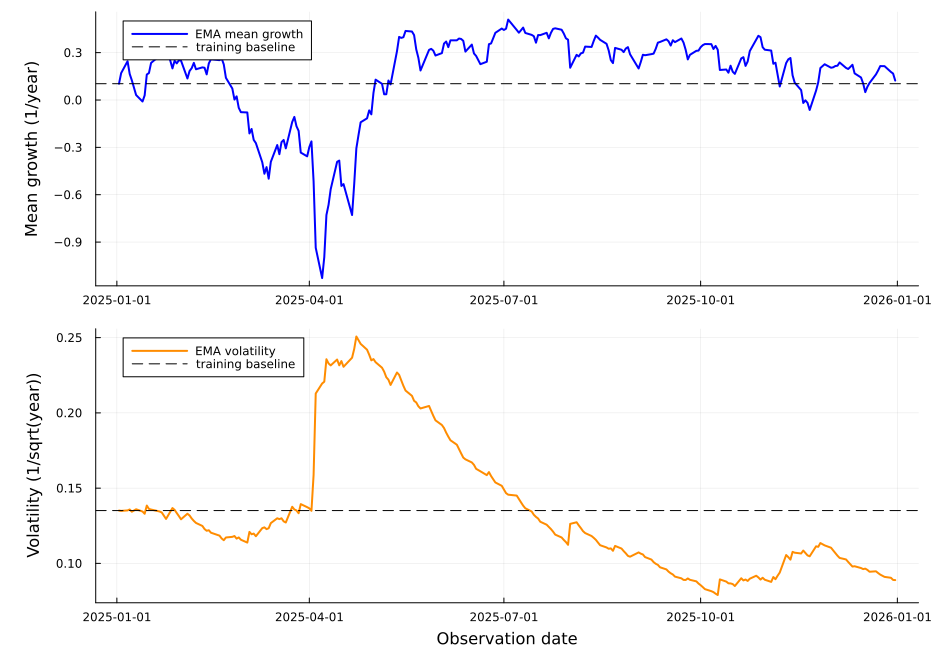

In [6]:
# Read the selected ticker's training baseline; do not fit it to 2025 prices -
parameter_row = findfirst(==(ticker_to_simulate), parameters_df.ticker);
baseline_mu_g = parameters_df.drift[parameter_row]; # training mean growth (1/year)
baseline_sigma = parameters_df.volatility[parameter_row]; # training volatility (1/sqrt(year))
# Follow the selected ticker's causal parameter states -
parameter_states = ema_gbm_parameters(prices, baseline_mu_g, baseline_sigma;
    start_index=start_day_index, dt=Δt, half_life=ema_half_life_days);
let
    dates = Date.(observation_dates[parameter_states.index]);
    p1 = plot(dates, parameter_states.mu_g; label="EMA mean growth", c=:blue, lw=2,
        ylabel="Mean growth (1/year)", legend=:topleft);
    hline!(p1, [baseline_mu_g]; label="training baseline", c=:black, ls=:dash);
    p2 = plot(dates, parameter_states.sigma; label="EMA volatility", c=:darkorange, lw=2,
        ylabel="Volatility (1/sqrt(year))", xlabel="Observation date", legend=:topleft);
    hline!(p2, [baseline_sigma]; label="training baseline", c=:black, ls=:dash);
    p = plot(p1,p2; layout=(2,1), size=(950,650), left_margin=8Plots.mm, right_margin=6Plots.mm);
    savefig(p, joinpath(_PATH_TO_FIGS,"L5a-ema-parameters.png"));
    p
end

The two panels show how the fitted mean growth and volatility respond to the same incoming observations. A moving estimate alone is not evidence of a better forecast. We need to record its probability and check that probability against the later outcome.

___

## Task 2: Compare Frozen and EMA Forecasts
In this task, we compare forecasts using frozen estimates, EMA updates to volatility alone, and EMA updates to both mean growth and volatility. The EMA methods share the same variance estimate.

Suppose we buy at row $s$ and make a forecast at row $k$ for a sale $H$ trading intervals later. The forecast spans $h$ years; discounting covers $T_k$ years from the purchase:

$$
h=H\Delta t,\qquad T_k=(k+H-s)\Delta t.
$$

For a purchase price $S_s$, an annual benchmark growth rate $g_y$, and a target $\rho_\star>-1$, the [NPV example](CHEME-5660-L5a-Example-GBM-NPV-TradeRule-Fall-2026.ipynb) gives the sale threshold and probability of exceeding it:

$$
\begin{aligned}
K_k&=S_s(1+\rho_\star)e^{g_yT_k},\\
p_k&=1-\Phi\!\left(\frac{\ln(K_k/S_k)-\hat\mu_{g,k}h}{\hat\sigma_k\sqrt h}\right).
\end{aligned}
$$

Here, $\Phi$ is the standard normal cumulative distribution function and $\hat\sigma_k>0$. We hold the parameters fixed within each forecast.

[The rolling_trade_forecasts(...) function](docs/adaptive-functions.md#rolling_trade_forecasts) records forecasts; [the score_trade_forecasts(...) function](docs/adaptive-functions.md#score_trade_forecasts) attaches later outcomes.


In [7]:
rolling_results = let
    tables = DataFrame[]; # each ticker contributes identical origins and three forecasting methods
    for ticker in list_of_tickers
        j = findfirst(==(ticker), parameters_df.ticker);
        asset_prices = Float64.(dataset[ticker].volume_weighted_average_price);
        forecasts = rolling_trade_forecasts(asset_prices, observation_dates,
            parameters_df.drift[j], parameters_df.volatility[j]; ticker,
            start_index=start_day_index, holding_days=holding_period_days, dt=Δt,
            half_life=ema_half_life_days, benchmark=g_y, target=rho_star);
        push!(tables, score_trade_forecasts(forecasts, asset_prices)); # attach later outcomes separately
    end
    reduce(vcat,tables)
end;
selected_results = rolling_results[rolling_results.ticker .== ticker_to_simulate, :];
method_order = ["Frozen", "EMA volatility", "EMA mean + volatility"];
println("Forecast origins per ticker and method: $(nrow(selected_results) ÷ 3)")
println("Every sale lies within the observed 2025 data; the purchase remains at row $(start_day_index).")


Forecast origins per ticker and method: 229
Every sale lies within the observed 2025 data; the purchase remains at row 1.


Plot the probabilities and later sale outcomes for the selected ticker, using forecast dates on the horizontal axis.


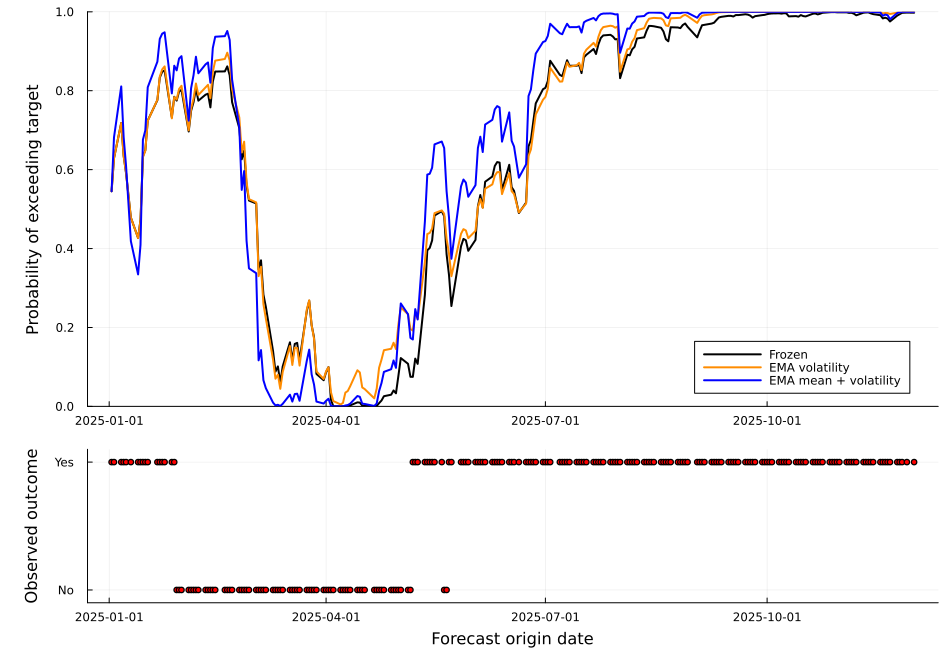

In [8]:
let
    colors = [:black, :darkorange, :blue];
    p1 = plot(; ylabel="Probability of exceeding target", ylim=(0,1), legend=:bottomright);
    for (i,method) in enumerate(method_order)
        rows = selected_results[selected_results.method .== method, :];
        plot!(p1, Date.(rows.origin_date), rows.probability; label=method, c=colors[i], lw=2);
    end
    rows = selected_results[selected_results.method .== "Frozen", :];
    p2 = scatter(Date.(rows.origin_date), Int.(rows.target_met); label="later sale exceeded target",
        c=:red, ms=3, ylabel="Observed outcome", yticks=([0,1],["No","Yes"]),
        ylim=(-0.1,1.1), xlabel="Forecast origin date", legend=false);
    p = plot(p1,p2; layout=grid(2,1,heights=[0.72,0.28]), size=(950,650), left_margin=8Plots.mm);
    savefig(p, joinpath(_PATH_TO_FIGS,"L5a-rolling-probabilities.png"));
    p
end


The methods give the same forecast at entry. Later probabilities change with prices, sale dates, and EMA estimates; the original purchase stays fixed.

### Simulate an Updated Forecast
Choose a date near the middle of the available forecasts. Use [the sample(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.sample-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}) to simulate each model from that day's price using the exact GBM transition. The panels share random draws and price limits; the red lines show the observed prices.


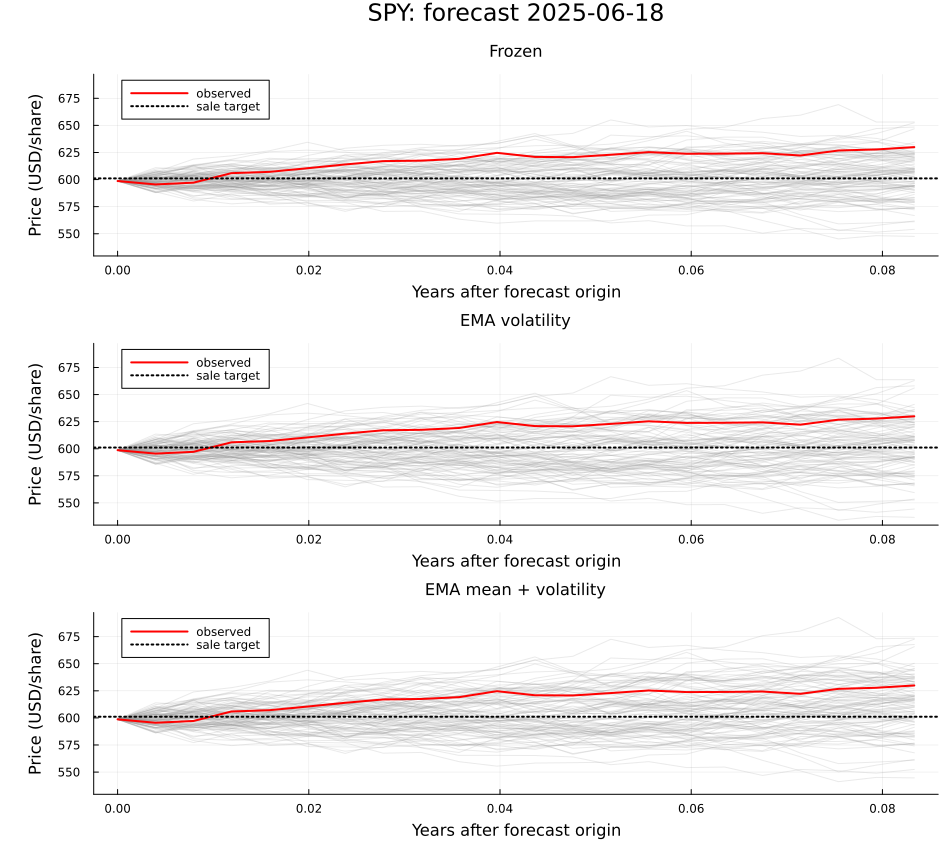

In [9]:
let
    # Select a valid origin automatically when the entry or holding period changes -
    origin = start_day_index + (length(prices)-holding_period_days-start_day_index) ÷ 2;
    rows = selected_results[selected_results.origin_index .== origin, :];
    panels = [];
    for method in method_order
        row = only(eachrow(rows[rows.method .== method, :]));
        local_model = build(MyGeometricBrownianMotionEquityModel,
            (μ=row.mu_g+0.5row.sigma^2, σ=row.sigma));
        Random.seed!(random_seed); # common random inputs make the model comparison easier to see
        paths = VLQuantitativeFinancePackage.sample(local_model,
            (Sₒ=row.current_price,T₁=0.0,T₂=holding_period_days*Δt,Δt=Δt);
            number_of_paths=number_of_paths);
        p = plot(paths[:,1],paths[:,2:end]; label=false, c=:gray60, alpha=0.2,
            title=method, titlefontsize=11, ylabel="Price (USD/share)", legend=:topleft);
        plot!(p, paths[:,1],prices[origin:origin+holding_period_days]; label="observed",c=:red,lw=2);
        hline!(p,[row.threshold]; label="sale target",c=:black,ls=:dot,lw=2);
        push!(panels,p);
    end
    # Give all three price panels identical limits so their spreads can be compared.
    limits = ylims.(panels);
    common_limits = (minimum(first.(limits)), maximum(last.(limits)));
    for panel in panels
        plot!(panel; ylims=common_limits);
    end
    p = plot(panels...;layout=(3,1),size=(950,850),xlabel="Years after forecast origin",
        left_margin=8Plots.mm, plot_title="$(ticker_to_simulate): forecast $(Date(observation_dates[origin]))");
    savefig(p,joinpath(_PATH_TO_FIGS,"L5a-updated-simulations.png"));
    p
end


Compare the final prices with the sale target. Volatility changes the spread; mean growth shifts the median. One path cannot establish which method predicts better.

___

## Task 3: Evaluate Whether Updating Helps
In this task, we compare methods using the same ticker/date pairs, benchmark, and target. For a probability $p_k$ and an outcome $y_k$ (one if the target is exceeded, zero otherwise), the mean Brier score over $Q$ forecasts is:

$$
\operatorname{Brier}=\frac{1}{Q}\sum_{k=1}^{Q}(p_k-y_k)^2.
$$

A lower score indicates more accurate probability forecasts. For $p_k=0.8$, the loss is $0.04$ if the target is exceeded and $0.64$ otherwise.

We first average the losses within each ticker, then average across tickers with equal weight. Each ticker has the same number of forecasts, so this is also the overall mean. The table also reports changes relative to the frozen model and the fraction of tickers for which the score improved.


In [10]:
# Compare paired outcomes first within tickers, then across the same eligible universe -
ticker_scores = combine(groupby(rolling_results, [:ticker,:method]),
    :brier_loss => mean => :mean_Brier, nrow => :origins);
baseline_scores = select(ticker_scores[ticker_scores.method .== "Frozen", :],
    :ticker, :mean_Brier => :frozen_Brier);
ticker_scores = leftjoin(ticker_scores, baseline_scores; on=:ticker);
ticker_scores.difference_from_frozen = ticker_scores.mean_Brier .- ticker_scores.frozen_Brier;
score_summary = combine(groupby(ticker_scores, :method),
    :mean_Brier => mean => :mean_Brier,
    :difference_from_frozen => mean => :difference_from_frozen,
    :difference_from_frozen => (x -> mean(x .< 0)) => :fraction_tickers_improved,
    :origins => sum => :forecast_count, nrow => :ticker_count);
println("Each method: $(first(score_summary.forecast_count)) forecasts across $(first(score_summary.ticker_count)) tickers")
pretty_table(Matrix(select(score_summary, :method, :mean_Brier, :difference_from_frozen,
    :fraction_tickers_improved));
    column_labels=["Method", "Mean Brier", "Change vs frozen", "Fraction improved"],
    formatters=[fmt__printf("%.5f",2:4)], fit_table_in_display_horizontally=false);


Each method: 95493 forecasts across 417 tickers
┌───────────────────────┬────────────┬──────────────────┬───────────────────┐
│                Method │ Mean Brier │ Change vs frozen │ Fraction improved │
├───────────────────────┼────────────┼──────────────────┼───────────────────┤
│                Frozen │    0.11662 │          0.00000 │           0.00000 │
│        EMA volatility │    0.11628 │         -0.00034 │           0.47722 │
│ EMA mean + volatility │    0.12235 │          0.00573 │           0.37650 │
└───────────────────────┴────────────┴──────────────────┴───────────────────┘


In the table, a negative value in **Change vs frozen** means lower average Brier loss. **Fraction improved** is the share of tickers with lower average loss than the frozen model.

In the plot, we average each forecast date's loss difference across tickers and add it to the running total. Below zero means less accumulated loss than the frozen model; above zero means more.


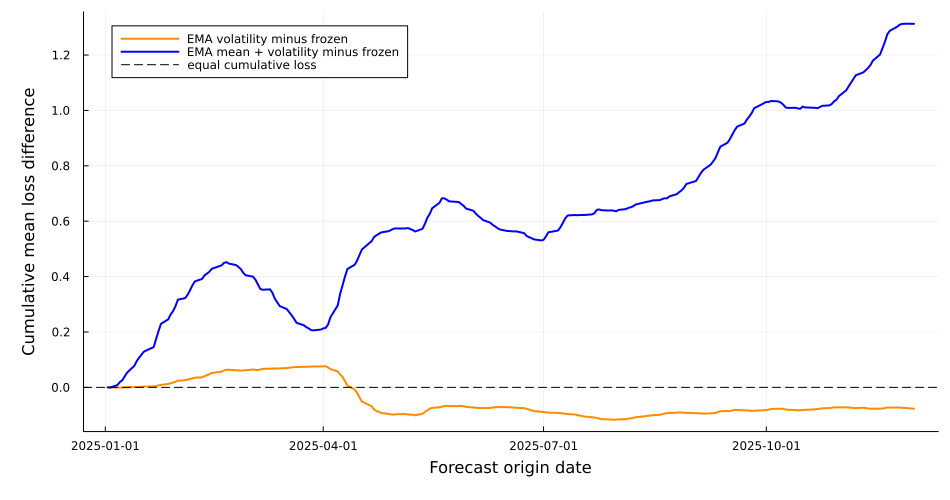

In [11]:
let
    daily = combine(groupby(rolling_results, [:origin_index,:method]), :brier_loss => mean => :loss);
    baseline = sort(daily[daily.method .== "Frozen", :], :origin_index);
    p = plot(; xlabel="Forecast origin date",ylabel="Cumulative mean loss difference",
        legend=:topleft, size=(950,500), left_margin=8Plots.mm, bottom_margin=8Plots.mm);
    for (method,color) in zip(method_order[2:end],[:darkorange,:blue])
        rows = sort(daily[daily.method .== method, :], :origin_index);
        plot!(p,Date.(observation_dates[rows.origin_index]),cumsum(rows.loss .- baseline.loss);
            label="$(method) minus frozen", c=color,lw=2);
    end
    hline!(p,[0.0];c=:black,ls=:dash,label="equal cumulative loss");
    savefig(p,joinpath(_PATH_TO_FIGS,"L5a-score-differences.png"));
    p
end


Overlapping windows and shared market movements make these losses dependent. Treat the comparison as a description of the 2025 evaluation, not a significance test based on independent trades. The 21-day EMA half-life was chosen before inspecting these scores. A lack of improvement is a useful result: responding more quickly to recent observations can also amplify noise.

Better probabilities do not imply greater trading profit here. Every method assesses the same original position and the same realized sale prices; we have not introduced a strategy that changes the position using the forecast.

The saved results also contain 95% coverage, interval width, and interval scores for the same forward window. These optional diagnostics use the growth rate over the forecast window, in $\mathrm{year}^{-1}$, for comparisons across tickers. Their definitions are in the [function reference](docs/adaptive-functions.md#supporting-interval-diagnostics).

___

## Summary
In this example, we initialized an EMA from the 2014–2024 GBM estimates, updated it using observed 2025 prices, and compared its forecasts with the frozen model.

> __Key Takeaways:__
>
> * **Exponential parameter updates:** We updated the mean and variance of observed growth rates, then recovered GBM volatility and arithmetic drift from those moments. The half-life determined how quickly older observations lost influence.
> * **Forecasts from the available observations:** We used each day's estimates to simulate prices and calculate a target probability over the next chosen window. Parameters stayed fixed within each forecast, while both frozen and EMA probabilities changed as prices and prospective sale dates changed.
> * **Measured forecast improvement:** We compared Brier losses on the same observed outcomes. This allowed us to assess the effects of updating volatility and mean growth separately, rather than assuming that a changing estimate must produce a better forecast.

Changing the half-life changes the balance between responding to recent observations and smoothing their noise. Its value should be chosen before evaluating the resulting forecasts.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
